<a href="https://colab.research.google.com/github/Jatin-Virmani/ML-Colabs/blob/main/Decision__Tree.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Decision Tree

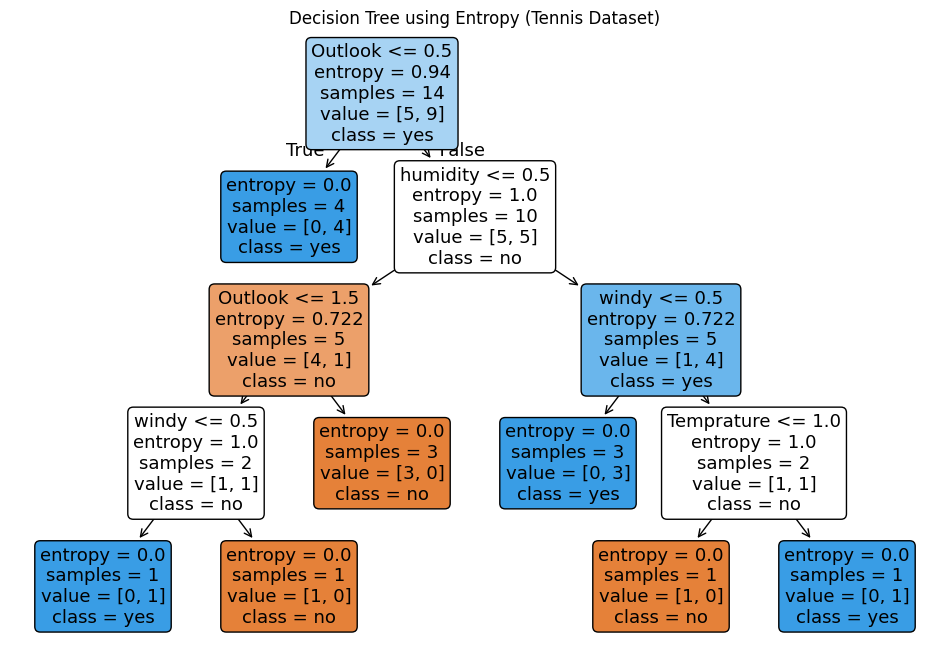

Decision Rules:

|--- Outlook <= 0.50
|   |--- class: 1
|--- Outlook >  0.50
|   |--- humidity <= 0.50
|   |   |--- Outlook <= 1.50
|   |   |   |--- windy <= 0.50
|   |   |   |   |--- class: 1
|   |   |   |--- windy >  0.50
|   |   |   |   |--- class: 0
|   |   |--- Outlook >  1.50
|   |   |   |--- class: 0
|   |--- humidity >  0.50
|   |   |--- windy <= 0.50
|   |   |   |--- class: 1
|   |   |--- windy >  0.50
|   |   |   |--- Temprature <= 1.00
|   |   |   |   |--- class: 0
|   |   |   |--- Temprature >  1.00
|   |   |   |   |--- class: 1



In [1]:
# Import libraries
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder
from sklearn.tree import DecisionTreeClassifier, plot_tree, export_text

# Step 1: Load dataset
df = pd.read_csv("Tennis.csv")

# Step 2: Separate features and target
X = df.drop(columns=['play tennis'])
y = df['play tennis']

# Step 3: Encode categorical data
encoders = {}
for col in X.columns:
    le = LabelEncoder()
    X[col] = le.fit_transform(X[col])
    encoders[col] = le

# Encode target variable
le_y = LabelEncoder()
y = le_y.fit_transform(y)

# Step 4: Train Decision Tree using ENTROPY
model = DecisionTreeClassifier(criterion='entropy', random_state=42)
model.fit(X, y)

# Step 5: Visualize Decision Tree
plt.figure(figsize=(12, 8))
plot_tree(
    model,
    feature_names=X.columns,
    class_names=le_y.classes_,
    filled=True,
    rounded=True
)
plt.title("Decision Tree using Entropy (Tennis Dataset)")
plt.show()

# Step 6: Print decision rules
print("Decision Rules:\n")
rules = export_text(model, feature_names=list(X.columns))
print(rules)